# Décision de nomination du portefeuille DE-LU

Le portefeuille combine Langer Wald (éolien) et Perleberg (solaire). Pour chaque quart d'heure, on compare trois nominations : P10, P50 et P90.

Cette partie reste strictement ex ante : elle utilise les prévisions de production et de prix, ainsi que les spreads historiques. Les réalisations ne seront utilisées qu'au settlement.

## Charger les scores et les décisions

La table des scores contient les trois candidats à chaque quart d'heure. La table des décisions conserve celui dont le PnL espéré est le plus élevé.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

score_path = PROJECT_ROOT / 'data/backtesting/nomination/de_lu_nomination_scores_20260701_20260831.parquet'
decision_path = PROJECT_ROOT / 'data/backtesting/nomination/de_lu_nomination_decisions_20260701_20260831.parquet'

backtest_path = PROJECT_ROOT / 'data/backtesting/nomination/de_lu_nomination_backtest_20260701_20260831.parquet'

scores = pd.read_parquet(score_path)
decisions = pd.read_parquet(decision_path)
backtest = pd.read_parquet(backtest_path)
scores['delivery_start_local'] = scores['delivery_start_utc'].dt.tz_convert('Europe/Berlin')
decisions['delivery_start_local'] = decisions['delivery_start_utc'].dt.tz_convert('Europe/Berlin')
backtest['delivery_date_local'] = backtest['delivery_start_utc'].dt.tz_convert('Europe/Berlin').dt.date

## Répartition des nominations retenues

Une décision est prise pour chaque quart d'heure. Cette vue montre si la règle utilise réellement les trois candidats ou favorise systématiquement l'un d'eux.

In [2]:
repartition = (
    decisions['strategy_name']
    .value_counts()
    .rename_axis('stratégie')
    .to_frame('quarts retenus')
)
repartition['part'] = repartition['quarts retenus'] / len(decisions)
repartition

,quarts retenus,part
stratégie,,
p10_prudente,5088,0.854839
p90_agressive,864,0.145161


## Voir les choix selon le bloc horaire

Les prix, le solaire et l'incertitude de production changent au cours de la journée. Le tableau aide à voir à quels moments P10 ou P90 est préféré.

In [3]:
heure = decisions['delivery_start_local'].dt.hour
decisions['bloc_horaire'] = pd.cut(
    heure,
    bins=[-1, 5, 11, 17, 23],
    labels=['00-05', '06-11', '12-17', '18-23'],
)

choix_par_bloc = pd.crosstab(
    decisions['bloc_horaire'],
    decisions['strategy_name'],
    normalize='index',
).mul(100).round(1)
choix_par_bloc

strategy_name,p10_prudente,p90_agressive
bloc_horaire,,
00-05,100.0,0.0
06-11,91.9,8.1
12-17,50.0,50.0
18-23,100.0,0.0


## Mesurer l'écart entre les candidats

La stratégie retenue peut gagner très largement ou de très peu. L'écart entre le meilleur et le deuxième score permet de distinguer les décisions nettes des quarts d'heure presque indifférents.

In [4]:
scores_tries = scores.sort_values(
    ['delivery_start_utc', 'expected_pnl_eur'],
    ascending=[True, False],
).copy()
scores_tries['rang'] = scores_tries.groupby('delivery_start_utc').cumcount()

deux_meilleurs = scores_tries.loc[scores_tries['rang'] < 2]
marges = deux_meilleurs.pivot(
    index='delivery_start_utc',
    columns='rang',
    values='expected_pnl_eur',
).rename(columns={0: 'meilleur_score_eur', 1: 'deuxieme_score_eur'})
marges['ecart_score_eur'] = marges['meilleur_score_eur'] - marges['deuxieme_score_eur']

marges['ecart_score_eur'].describe().round(2)

count    5952.00
mean       10.19
std        12.99
min         0.00
25%         2.54
50%         5.34
75%        10.64
max        71.63
Name: ecart_score_eur, dtype: float64

## Comparer les trois candidats sur une journée

Les montants ci-dessous sont la somme des PnL espérés des quarts de la journée. C'est un diagnostic : la règle elle-même choisit séparément la meilleure nomination à chaque quart d'heure.

In [5]:
jour_etudie = pd.Timestamp('2026-07-19').date()

scores_jour = scores.loc[
    scores['delivery_start_local'].dt.date == jour_etudie
].copy()

comparaison_jour = (
    scores_jour.groupby('strategy_name', as_index=False)
    .agg(pnl_espere_eur=('expected_pnl_eur', 'sum'))
    .sort_values('pnl_espere_eur', ascending=False)
)
comparaison_jour

,strategy_name,pnl_espere_eur
0,p10_prudente,30209.687656
1,p50_centrale,29306.989820
2,p90_agressive,28502.703335


## Examiner une décision précise

On affiche les trois candidats d'un même quart d'heure. Le maximum de `expected_pnl_eur` doit correspondre à la ligne retenue dans la table des décisions.

In [6]:
quart_etudie = pd.Timestamp('2026-07-19 12:00', tz='Europe/Berlin')

comparaison_quart = scores.loc[
    scores['delivery_start_local'] == quart_etudie,
    ['strategy_name', 'nomination_mwh', 'expected_pnl_eur'],
].sort_values('expected_pnl_eur', ascending=False)

decision_quart = decisions.loc[
    decisions['delivery_start_local'] == quart_etudie,
    ['strategy_name', 'nomination_mwh', 'expected_pnl_eur'],
]

display(comparaison_quart)
display(decision_quart)

,strategy_name,nomination_mwh,expected_pnl_eur
5330,p90_agressive,10.583790,109.943370
5329,p50_centrale,9.844979,109.464597
5328,p10_prudente,7.775442,108.123473


,strategy_name,nomination_mwh,expected_pnl_eur
1776,p90_agressive,10.58379,109.94337


## Confronter les nominations aux réalisations

La décision est maintenant figée. Le settlement utilise seulement à cette étape la production réelle, le prix Day-Ahead réalisé et le reBAP appliqué à l'écart.

In [ ]:
resume_financier = (
    backtest.groupby('policy_name')
    .agg(
        revenu_da_eur=('day_ahead_revenue_eur', 'sum'),
        reglement_ecart_eur=('imbalance_settlement_eur', 'sum'),
        pnl_brut_eur=('gross_pnl_eur', 'sum'),
    )
)

position_physique = (
    backtest.groupby('policy_name')
    .agg(
        imbalance_net_mwh=('imbalance_volume_mwh', 'sum'),
        surplus_mwh=('imbalance_volume_mwh', lambda values: values.clip(lower=0).sum()),
        shortfall_mwh=('imbalance_volume_mwh', lambda values: values.clip(upper=0).sum()),
        ecart_absolu_mwh=('imbalance_volume_mwh', lambda values: values.abs().sum()),
    )
)

resume_settlement = resume_financier.join(position_physique)
resume_settlement.round(0)

,revenu_da_eur,reglement_ecart_eur,pnl_brut_eur,imbalance_net_mwh,surplus_mwh,shortfall_mwh,ecart_absolu_mwh
policy_name,,,,,,,
always_p10_prudente,1130494.0,598275.0,1728769.0,5528.0,6934.0,-1406.0,8339.0
always_p50_centrale,2006401.0,-340500.0,1665901.0,-2621.0,2109.0,-4730.0,6839.0
always_p90_agressive,3185461.0,-1595002.0,1590459.0,-12866.0,305.0,-13171.0,13476.0
dynamic_expected_pnl,1269716.0,454686.0,1724402.0,2504.0,5814.0,-3311.0,9125.0


Le point essentiel est que la stratégie dynamique post-settlement ne constitue pas une nouvelle décision : elle rejoue exactement les nominations choisies ex ante. La composition est donc identique par construction : **85,5 % de P10** et **14,5 % de P90**, sans P50.

Les résultats financiers, eux, diffèrent : le PnL espéré ex ante de la stratégie dynamique est de **1,845 M€**, contre **1,724 M€** réalisés après livraison, soit un écart d'environ **-121 k€**. Cet écart mesure la différence entre les hypothèses disponibles au cutoff et les réalisations de production, de prix DA et de reBAP. Il ne faut donc pas présenter le post-settlement comme une seconde stratégie indépendante.

Un écart positif correspond à un surplus de production ; un écart négatif correspond à un manque. L'écart net peut se compenser sur deux mois : les colonnes surplus et manque montrent donc le sens réel des positions.

## Composition de la stratégie dynamique

Les trois politiques fixes nominent toujours le même quantile. Sur cette période, la stratégie dynamique retient P10 sur **85,5 %** des quarts et P90 sur **14,5 %** ; elle ne retient jamais P50. Elle se comporte donc comme une politique P10 avec quelques bascules vers P90, et non comme un véritable compromis entre les trois scénarios.

Cette répartition est un diagnostic du score ex ante, pas une preuve que P10 ou P90 est optimal. Elle doit être évaluée sur une période indépendante avant toute conclusion opérationnelle.

In [8]:
composition_dynamique = (
    decisions['strategy_name']
    .value_counts()
    .rename_axis('quantile retenu')
    .to_frame('quarts retenus')
)
composition_dynamique['part'] = (
    composition_dynamique['quarts retenus'] / len(decisions)
)
composition_dynamique

,quarts retenus,part
quantile retenu,,
p10_prudente,5088,0.854839
p90_agressive,864,0.145161


La table de décision révèle aussi une structure horaire : la stratégie dynamique choisit P10 dans **100 %** des quarts 00–05 et 18–23, tandis que le bloc 12–17 est partagé à parts égales entre P10 et P90. Les choix P90 se concentrent donc principalement sur les heures de production solaire et de risque de compensation.

P10 fixe obtient le meilleur PnL sur cette période, mais une grande partie de ce résultat vient du règlement d'écart positif. P50 minimise les écarts physiques. Le classement dépend donc du comportement observé du reBAP sur juillet-août et ne suffit pas à valider la règle ex ante.

## Mesurer les pires journées

Le PnL total ne suffit pas. Le tableau compare la moyenne, la médiane, le P10 des journées, l'écart-type, le pire jour, le meilleur jour et la part de journées positives. Cette lecture distingue une performance moyenne élevée d'une politique réellement régulière et permet de repérer les résultats dominés par quelques événements extrêmes.

In [14]:
pnl_journalier = backtest.groupby(['policy_name', 'delivery_date_local'])['gross_pnl_eur'].sum()
daily_pnl_frame = pnl_journalier.rename('pnl_jour_eur').reset_index()

risque_journalier = (
    daily_pnl_frame.groupby('policy_name')
    .agg(
        pnl_moyen_jour_eur=('pnl_jour_eur', 'mean'),
        pnl_median_jour_eur=('pnl_jour_eur', 'median'),
        pnl_p10_jour_eur=('pnl_jour_eur', lambda values: values.quantile(0.10)),
        ecart_type_jour_eur=('pnl_jour_eur', 'std'),
        pire_jour_eur=('pnl_jour_eur', 'min'),
        meilleur_jour_eur=('pnl_jour_eur', 'max'),
        jours_positifs=('pnl_jour_eur', lambda values: int((values > 0).sum())),
        jours_total=('pnl_jour_eur', 'size'),
    )
)
risque_journalier['part_jours_positifs_pct'] = (
    100 * risque_journalier['jours_positifs'] / risque_journalier['jours_total']
)
risque_journalier.sort_values('pnl_moyen_jour_eur', ascending=False).round(0)

,pnl_moyen_jour_eur,pnl_median_jour_eur,pnl_p10_jour_eur,ecart_type_jour_eur,pire_jour_eur,meilleur_jour_eur,jours_positifs,jours_total,part_jours_positifs_pct
policy_name,,,,,,,,,
always_p10_prudente,27883.0,25942.0,13174.0,15180.0,4012.0,92942.0,62,62,100.0
dynamic_expected_pnl,27813.0,24980.0,13190.0,15131.0,3734.0,92942.0,62,62,100.0
always_p50_centrale,26869.0,25253.0,12993.0,13759.0,-11870.0,67297.0,61,62,98.0
always_p90_agressive,25653.0,24223.0,10979.0,14218.0,-32454.0,55466.0,61,62,98.0


## Visualiser les trajectoires de PnL

Cette courbe permet de voir si le résultat vient d'une évolution régulière ou de quelques journées isolées.

C:\Users\djamo\AppData\Local\Temp\ipykernel_5284\2710766076.py:7: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


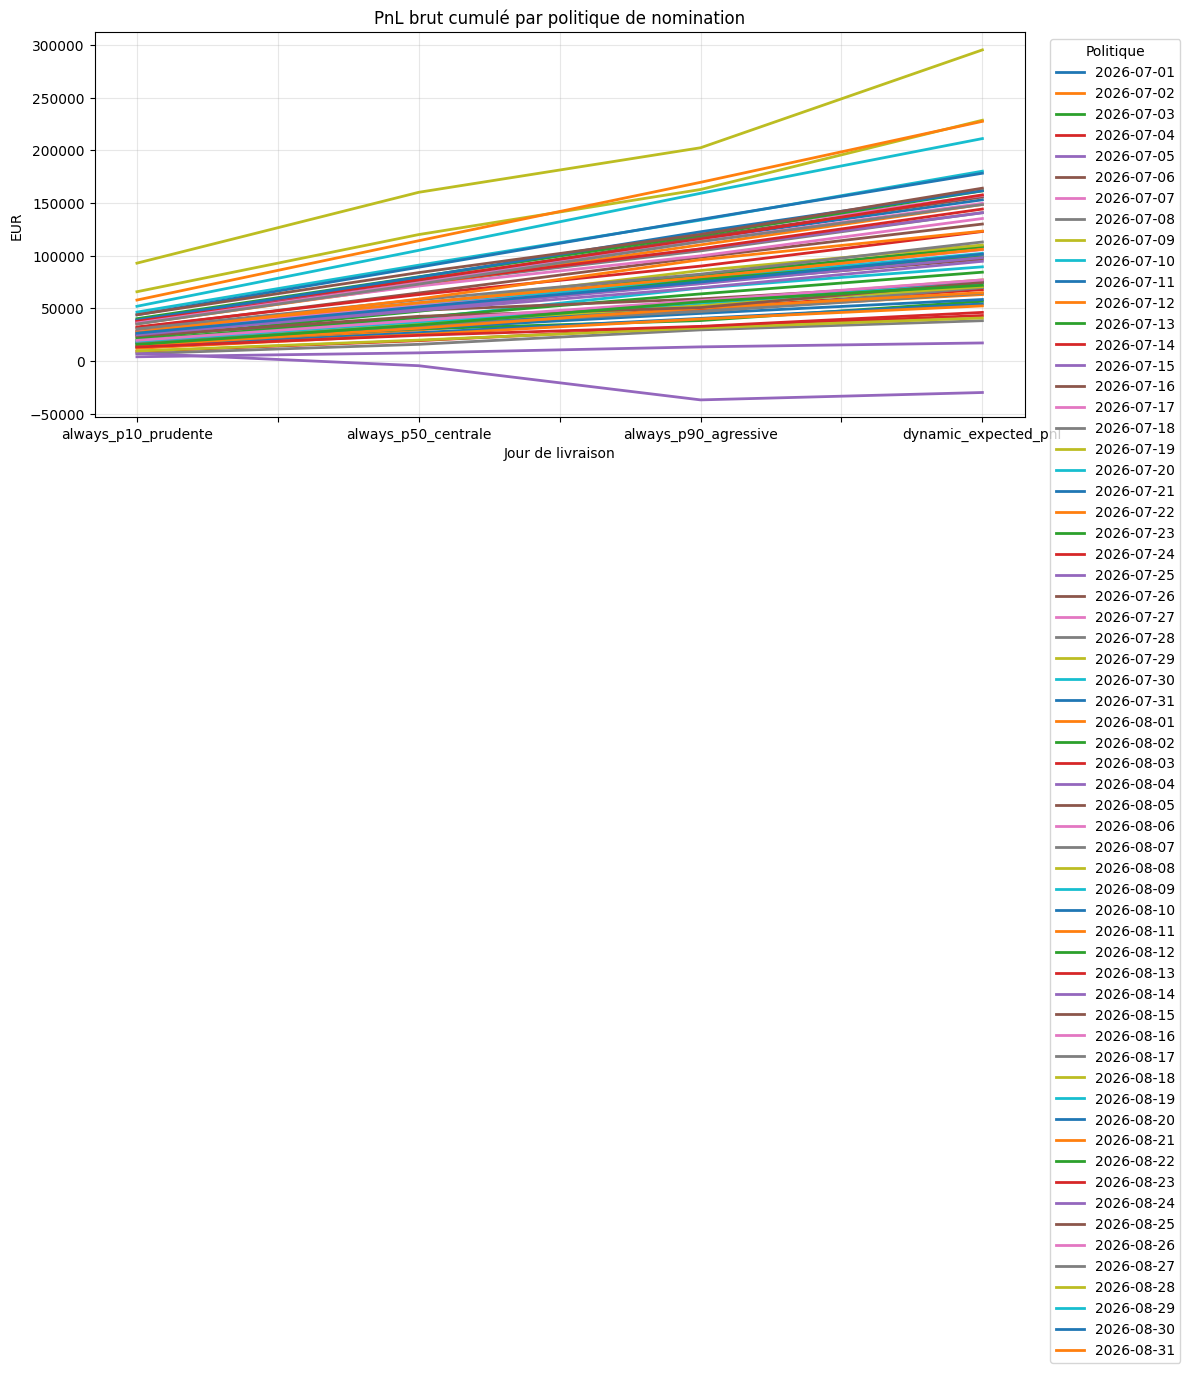

In [10]:
pnl_journalier.unstack().cumsum().plot(figsize=(12, 5), linewidth=2)
plt.title('PnL brut cumulé par politique de nomination')
plt.ylabel('EUR')
plt.xlabel('Jour de livraison')
plt.grid(alpha=0.3)
plt.legend(title='Politique', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Limites et conclusion

- Les scénarios de prix et de production sont supposés indépendants.
- Le reBAP est utilisé après livraison pour le settlement ; il n'est pas connu lors de la nomination.
- Le PnL est brut : frais, intraday, contrats et curtailment ne sont pas inclus.
- La fenêtre couvre juillet-août seulement ; elle ne suffit pas à généraliser une politique.

Sur cette fenêtre, P10 fixe obtient le meilleur PnL réalisé, mais son avantage vient en partie du règlement d'écart positif. P50 présente le meilleur compromis physique avec **6 839 MWh** d'écart absolu, contre **8 339 MWh** pour P10 et **13 476 MWh** pour P90. La stratégie dynamique réalise presque le PnL de P10, mais elle sélectionne uniquement P10 et P90 et ne choisit jamais P50.

La comparaison ex ante/post doit donc être lue comme une évaluation de cohérence et de risque, pas comme une preuve d'optimalité. Le score ex ante n'observe pas la production, le prix DA ou le reBAP réalisés ; le classement postérieur dépend notamment des conditions de marché et des signes du reBAP sur cette courte période. Une validation sur une période indépendante est nécessaire avant toute recommandation opérationnelle.